In [1]:
! pip install mlflow


[notice] A new release of pip is available: 24.1.1 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('../data/housing_normalized.csv')
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.000000,0.2,0.073442,0.0,0.309129,0.577505,0.628998,0.308996,0.000000,0.225941,0.287234,0.089680,0.422222
1,0.000411,0.0,0.262406,0.0,0.165975,0.547998,0.775053,0.400545,0.043478,0.112971,0.553191,0.204470,0.368889
2,0.000410,0.0,0.262406,0.0,0.165975,0.694386,0.585288,0.400545,0.043478,0.112971,0.553191,0.063466,0.660000
3,0.000509,0.0,0.068281,0.0,0.143154,0.658555,0.422175,0.514848,0.086957,0.071130,0.648936,0.033389,0.631111
4,0.001227,0.0,0.068281,0.0,0.143154,0.687105,0.511727,0.514848,0.086957,0.071130,0.648936,0.099338,0.693333
...,...,...,...,...,...,...,...,...,...,...,...,...,...
450,0.001101,0.0,0.455339,0.0,0.381743,0.580954,0.670576,0.140804,0.000000,0.177824,0.893617,0.219095,0.386667
451,0.000762,0.0,0.455339,0.0,0.381743,0.490324,0.751599,0.120858,0.000000,0.177824,0.893617,0.202815,0.346667
452,0.001065,0.0,0.455339,0.0,0.381743,0.654340,0.904051,0.108332,0.000000,0.177824,0.893617,0.107892,0.420000
453,0.002020,0.0,0.455339,0.0,0.381743,0.619467,0.885928,0.131441,0.000000,0.177824,0.893617,0.131071,0.377778


In [4]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
X.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT
0,0.000000,0.2,0.073442,0.0,0.309129,0.577505,0.628998,0.308996,0.000000,0.225941,0.287234,0.089680
1,0.000411,0.0,0.262406,0.0,0.165975,0.547998,0.775053,0.400545,0.043478,0.112971,0.553191,0.204470
2,0.000410,0.0,0.262406,0.0,0.165975,0.694386,0.585288,0.400545,0.043478,0.112971,0.553191,0.063466
3,0.000509,0.0,0.068281,0.0,0.143154,0.658555,0.422175,0.514848,0.086957,0.071130,0.648936,0.033389
4,0.001227,0.0,0.068281,0.0,0.143154,0.687105,0.511727,0.514848,0.086957,0.071130,0.648936,0.099338


In [5]:
y.head()

0    0.422222
1    0.368889
2    0.660000
3    0.631111
4    0.693333
Name: MEDV, dtype: float64

## Treinamento

In [6]:
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
import numpy as np

#### Como temos um conjunto de dados reduzido, seria uma boa ideia utilizar K-Fold Cross Validation

In [7]:
import mlflow
import numpy as np
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mlflow.set_tracking_uri(uri="http://127.0.0.1:6002")
mlflow.set_experiment("housing")

kf = KFold(n_splits=5, random_state=42, shuffle=True)

models = {
    "linear": LinearRegression(),
    "tree": DecisionTreeRegressor(random_state=42),
    "rf": RandomForestRegressor(random_state=42)
}

for model_name, model in models.items():
    mae_scores = []
    mse_scores = []
    r2_scores = []
    with mlflow.start_run():
        for fold, (train_index, val_index) in enumerate(kf.split(X)):
            X_train, X_val = X.iloc[train_index], X.iloc[val_index]
            y_train, y_val = y.iloc[train_index], y.iloc[val_index]
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)
            
            mae = mean_absolute_error(y_val, y_pred)
            mse = mean_squared_error(y_val, y_pred)
            r2 = r2_score(y_val, y_pred)
            
            mae_scores.append(mae)
            mse_scores.append(mse)
            r2_scores.append(r2)
            
            mlflow.log_metric(f"mae_{fold}", mae)
            mlflow.log_metric(f"mse_{fold}", mse)
            mlflow.log_metric(f"r2_{fold}", r2)
        
        mean_mae = np.mean(mae_scores)
        mean_mse = np.mean(mse_scores)
        mean_r2 = np.mean(r2_scores)
        
        mlflow.log_metric("mean_mae", mean_mae)
        mlflow.log_metric("mean_mse", mean_mse)
        mlflow.log_metric("mean_r2", mean_r2)

        if hasattr(model, "get_params"):
            mlflow.log_params(model.get_params())
        
        print(f"MODEL {model_name}: MAE {mean_mae}, MSE {mean_mse}, R2 {mean_r2}")

MODEL linear: MAE 0.07778213420972528, MSE 0.012363679320103496, R2 0.676104610055053
🏃 View run rebellious-pig-879 at: http://127.0.0.1:6002/#/experiments/1/runs/1cfdf50123c6472eb16c8ba81763152e
🧪 View experiment at: http://127.0.0.1:6002/#/experiments/1
MODEL tree: MAE 0.0698949938949939, MSE 0.012065695292361959, R2 0.662439180799996
🏃 View run righteous-snake-187 at: http://127.0.0.1:6002/#/experiments/1/runs/e962db48c610403bb3cb6617ec89be9a
🧪 View experiment at: http://127.0.0.1:6002/#/experiments/1
MODEL rf: MAE 0.05165250305250304, MSE 0.005901472535069868, R2 0.8410259695884952
🏃 View run exultant-ram-696 at: http://127.0.0.1:6002/#/experiments/1/runs/ba2e3d7540d043efa646df50b56ca2f5
🧪 View experiment at: http://127.0.0.1:6002/#/experiments/1


#### Os resultados da regressão linear utilzando MAE (mean absolute error), R^2 e MSE (Mean Square Error) para avaliar a performance. Acompanhado com os hiperparametros utilizados


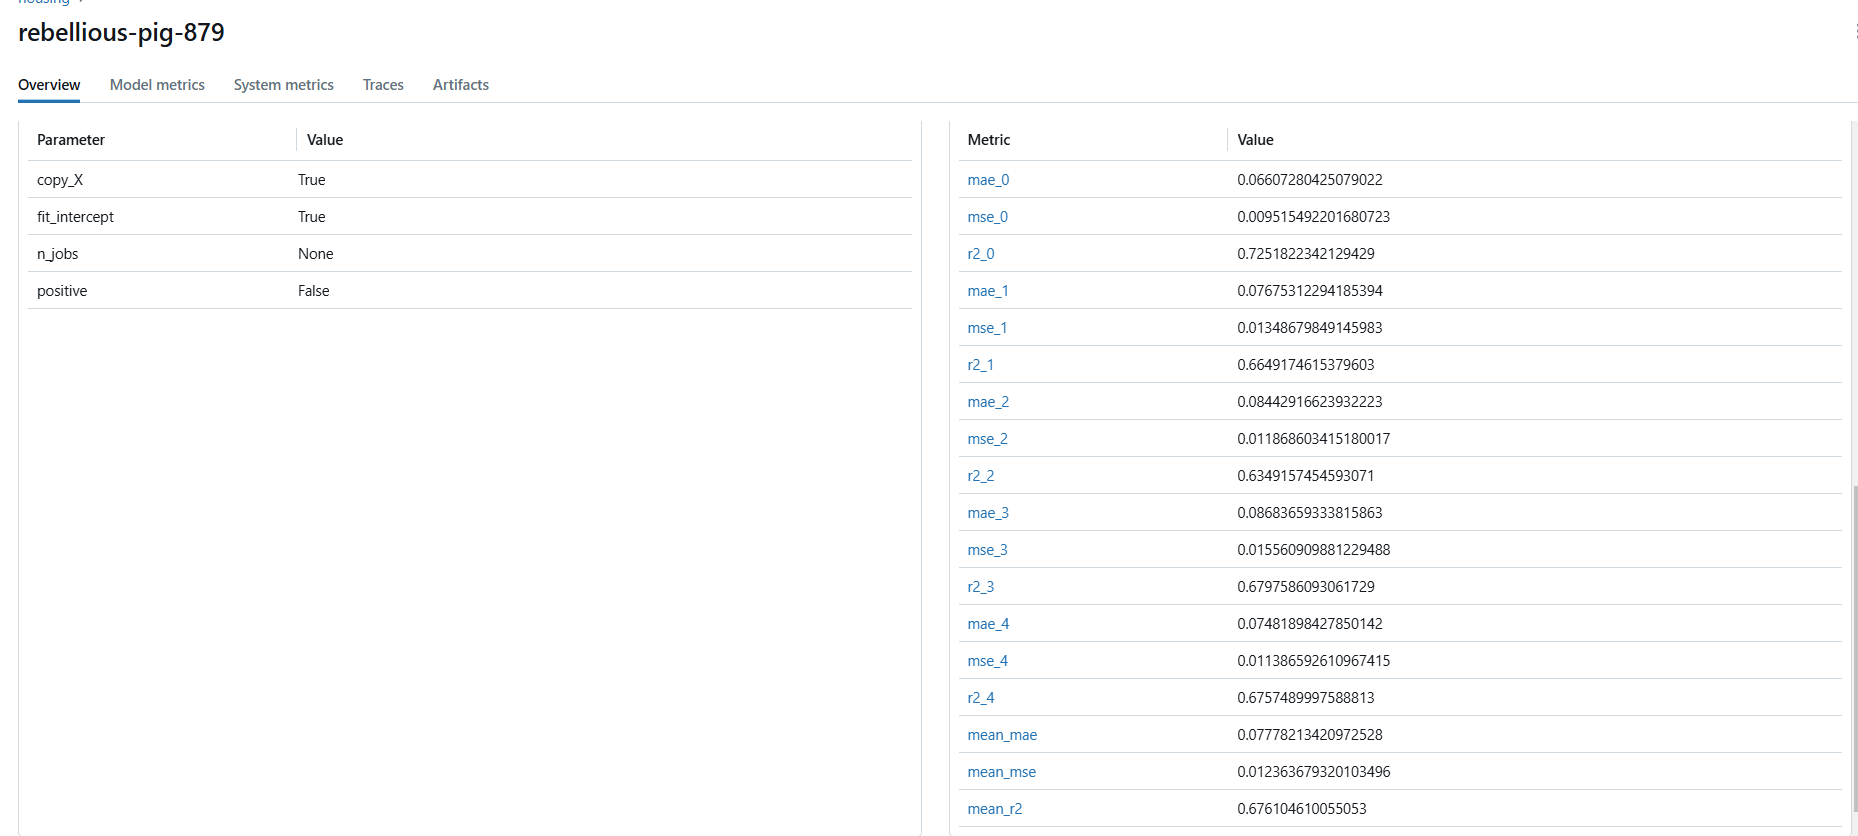

#### Resultados da arvore de decisão

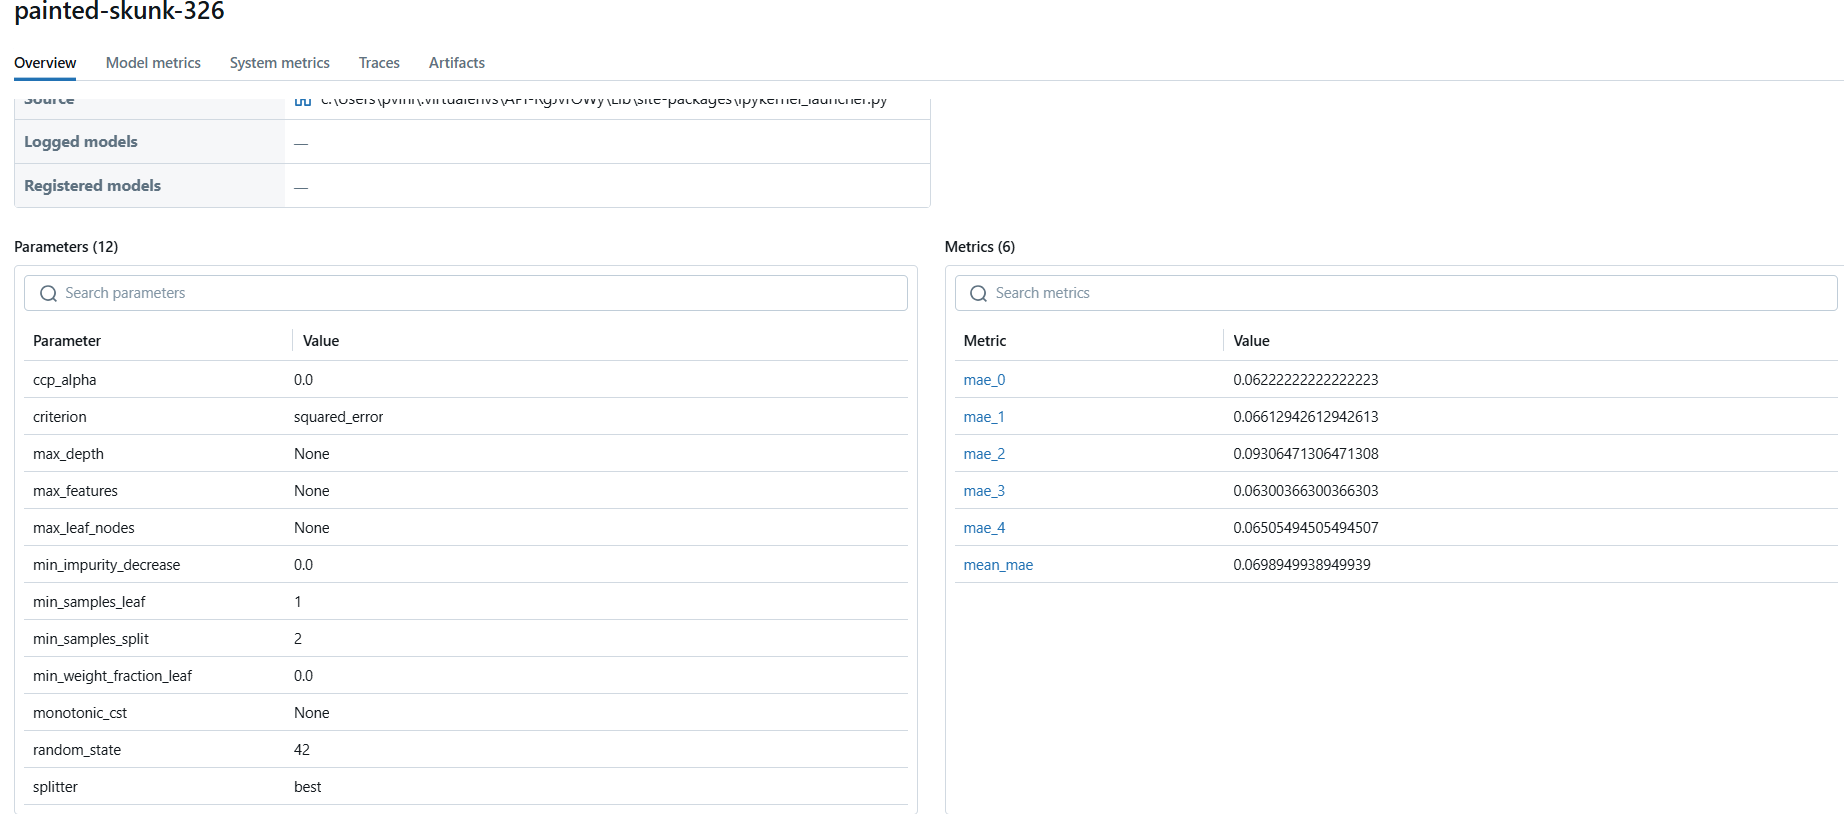


#### Resultados da Random Forest

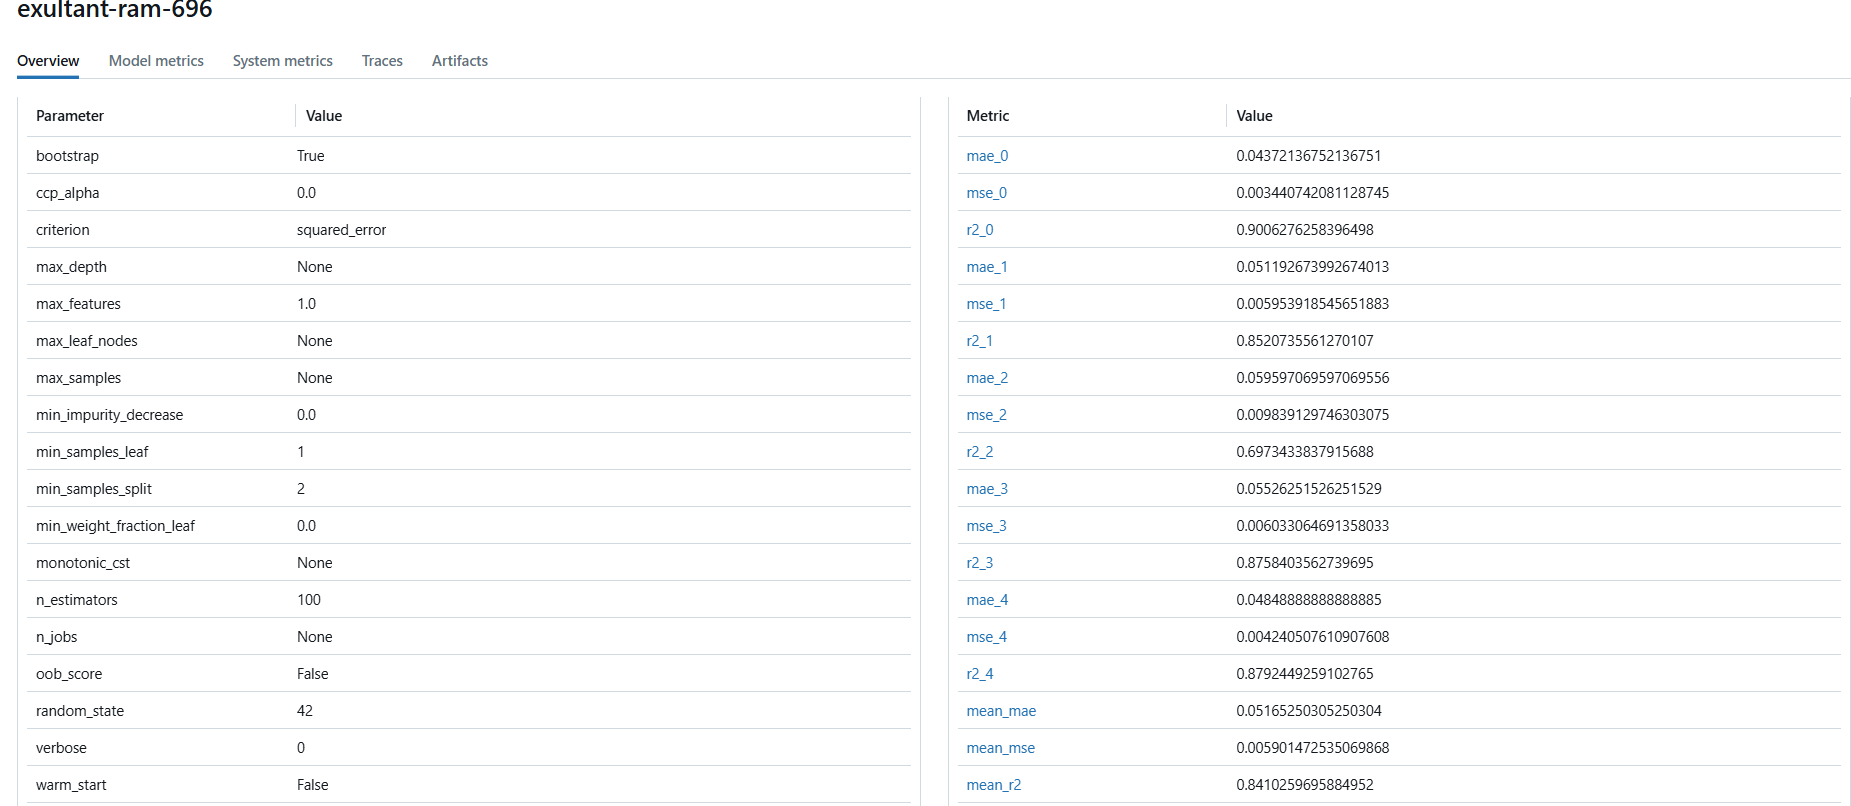


### Experimentos Executados

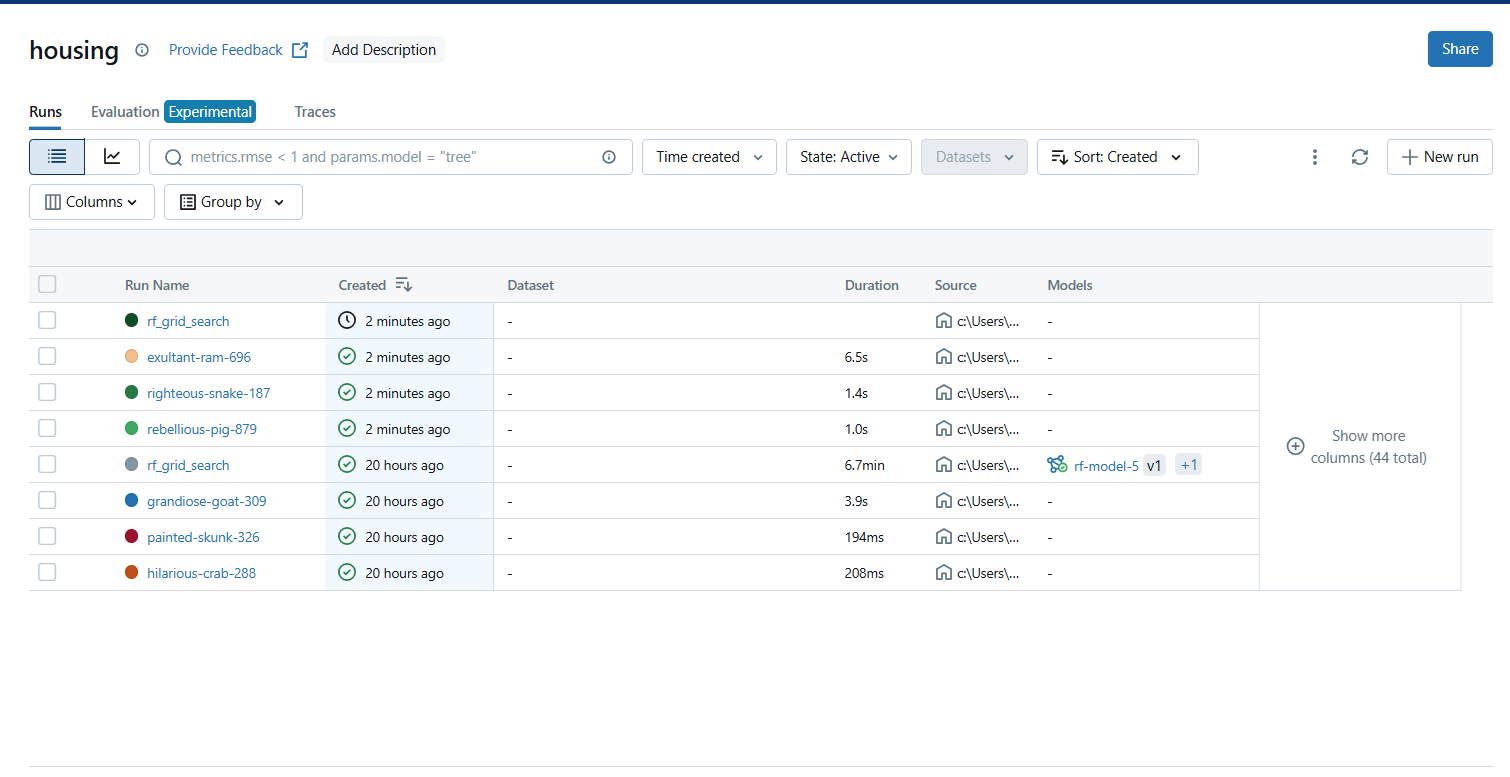

Comparando os a arvore de decisão e a regressão linear, podemos dizer que a arvore de decisão se saiu melhor. Os dados não possuem relações lineares altas  e a distribuição dos dados que não é gaussiana faz com que a regressão linear, um algoritmo que pressupõe linearidade entre as variáveis não consiga se adaptar, diferente da árvore de decisão que consegue se adaptar melhor com relação não lineares entre as variaveis.


Posteriormente foi decidido fazer testes com o Random Forest, que obteve resultados melhores que as a arvore de decisão. Talvez a Randoom Forest não sofra tanto de overfitting quanto as arvores de decisão

Sendo assim o melhor modelo foi Random Forest com uma o R^2 de 0.8 significando que o modelo consegue explicar mais de 80% da variabilidade do preço mediano de casas em Boston, outra métrica seria o MAE que chegou a  0.05 (em escala normalizada) 5% aproximadamente de diferença do valor real, porém essa métrica nâo leve em conta o impacto real do erro, pois trata todos os erros com o mesmo peso. Utilizando a MSE (Mean Square Error) podemos ter a visibilidade um pouco melhor do impacto dos erros, pois erros maiores são mais penalizados devido ao calculo da métrica. A Random Forest obteve um MSE médio de 0.005... isso poderia ser melhor mas está razoavelmente bom. Para fazer melhorias vamos ajustar os hiperparametros e depois realizar o log das métricas no MLFlow

In [8]:
import mlflow
import mlflow.sklearn
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mlflow.set_tracking_uri("http://127.0.0.1:6002")
mlflow.set_experiment("housing")

# Parâmetros para o Random Forest
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search_rf = GridSearchCV(RandomForestRegressor(), param_grid_rf, cv=5, scoring='neg_mean_absolute_error')

# Otimização para Random Forest
with mlflow.start_run(run_name="rf_grid_search"):
    grid_search_rf.fit(X, y)

    best_model = grid_search_rf.best_estimator_
    best_params = grid_search_rf.best_params_
    best_score = -grid_search_rf.best_score_

    input_example = X.iloc[[0]]

    mlflow.log_params(best_params)
    mlflow.log_metric("mae", best_score)
    mlflow.sklearn.log_model(best_model, "rf-model-5", input_example=input_example)

    # Calcular e registrar métricas adicionais
    y_pred = best_model.predict(X)
    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)

    mlflow.log_metric("mse", mse)
    mlflow.log_metric("r2", r2)

    # Registrar o modelo no Model Registry
    model_uri = "runs:/{}/rf-model".format(mlflow.active_run().info.run_id)
    model_name = "rf-model-5"
    
    registered_model = mlflow.register_model(model_uri, model_name)

    print(f"Modelo registrado com sucesso: {registered_model.name}, versão: {registered_model.version}")
    print(f"MAE: {best_score}, MSE: {mse}, R2: {r2}")

Registered model 'rf-model-5' already exists. Creating a new version of this model...
2025/01/28 09:07:42 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: rf-model-5, version 2


Modelo registrado com sucesso: rf-model-5, versão: 2
MAE: 0.0657653968253968, MSE: 0.0007467226571699927, R2: 0.9804901167668937
🏃 View run rf_grid_search at: http://127.0.0.1:6002/#/experiments/1/runs/e4dacdb08baf4efcbea269210c45f176
🧪 View experiment at: http://127.0.0.1:6002/#/experiments/1


Created version '2' of model 'rf-model-5'.


In [13]:
print("Melhores hiperparâmetros para Random Forest:", grid_search_rf.best_params_)

best_rf_model = grid_search_rf.best_estimator_

Melhores hiperparâmetros para Random Forest: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


### Performance da Random Forest depois de otimização de hiperparametros

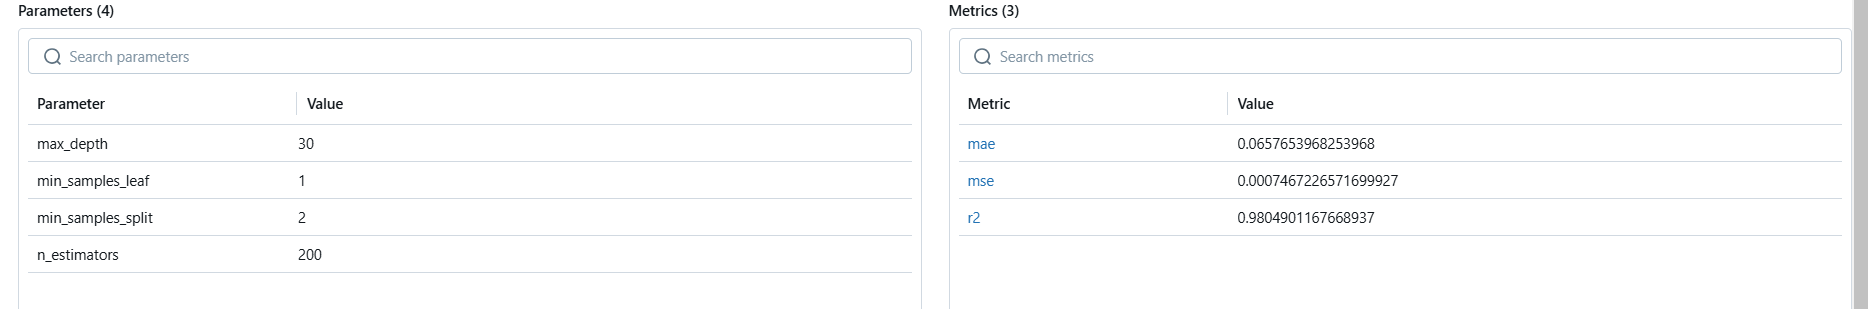

Após a otimização de hiperparametro o resultados foram bem melhores:

- **R^2** de 0.98, o modelo consegue explicar 98% da variabilidade nos preços medianos de imóveis em boston
- **MSE** de 0.0007, o modelo está comentendo erros muito pequenos.
- **MAE** 0.065 embora o erro não esteja em zero, o resultado é razoavelmente bom



#### Depois de escolhermos o modelo com melhor performance, criamos nosso modelo final sendo representado pelo modelo com Algoritmo de Random Forest, e loggamos finalmente o modelo



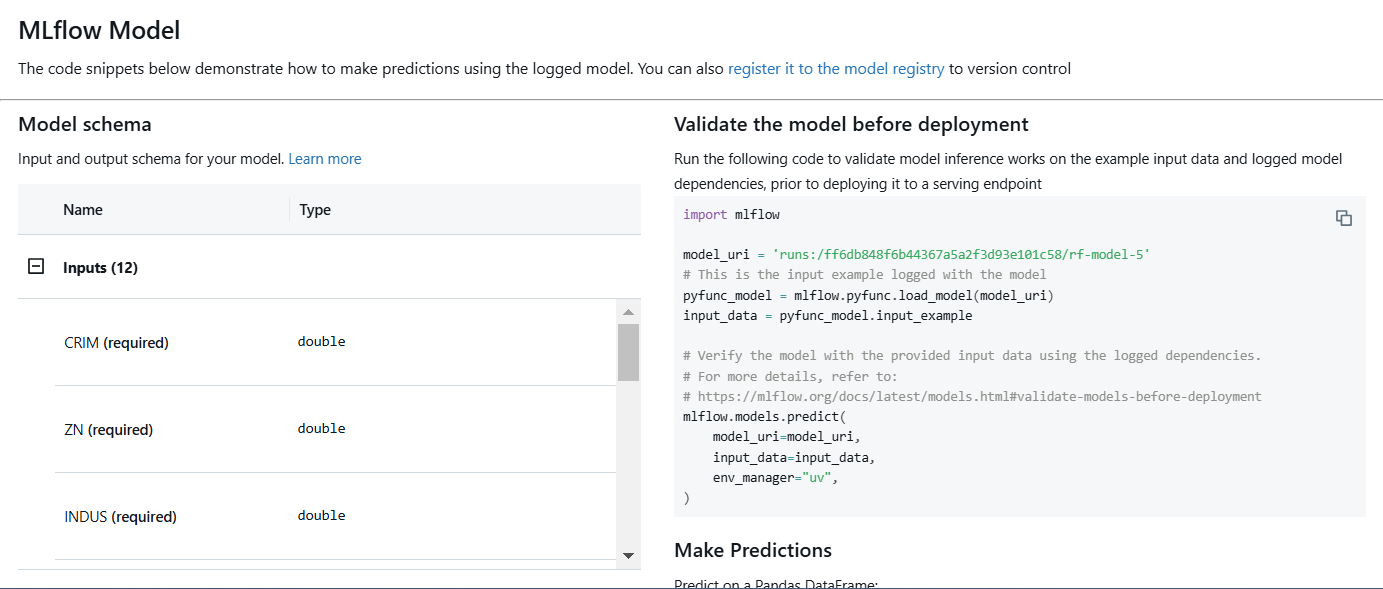
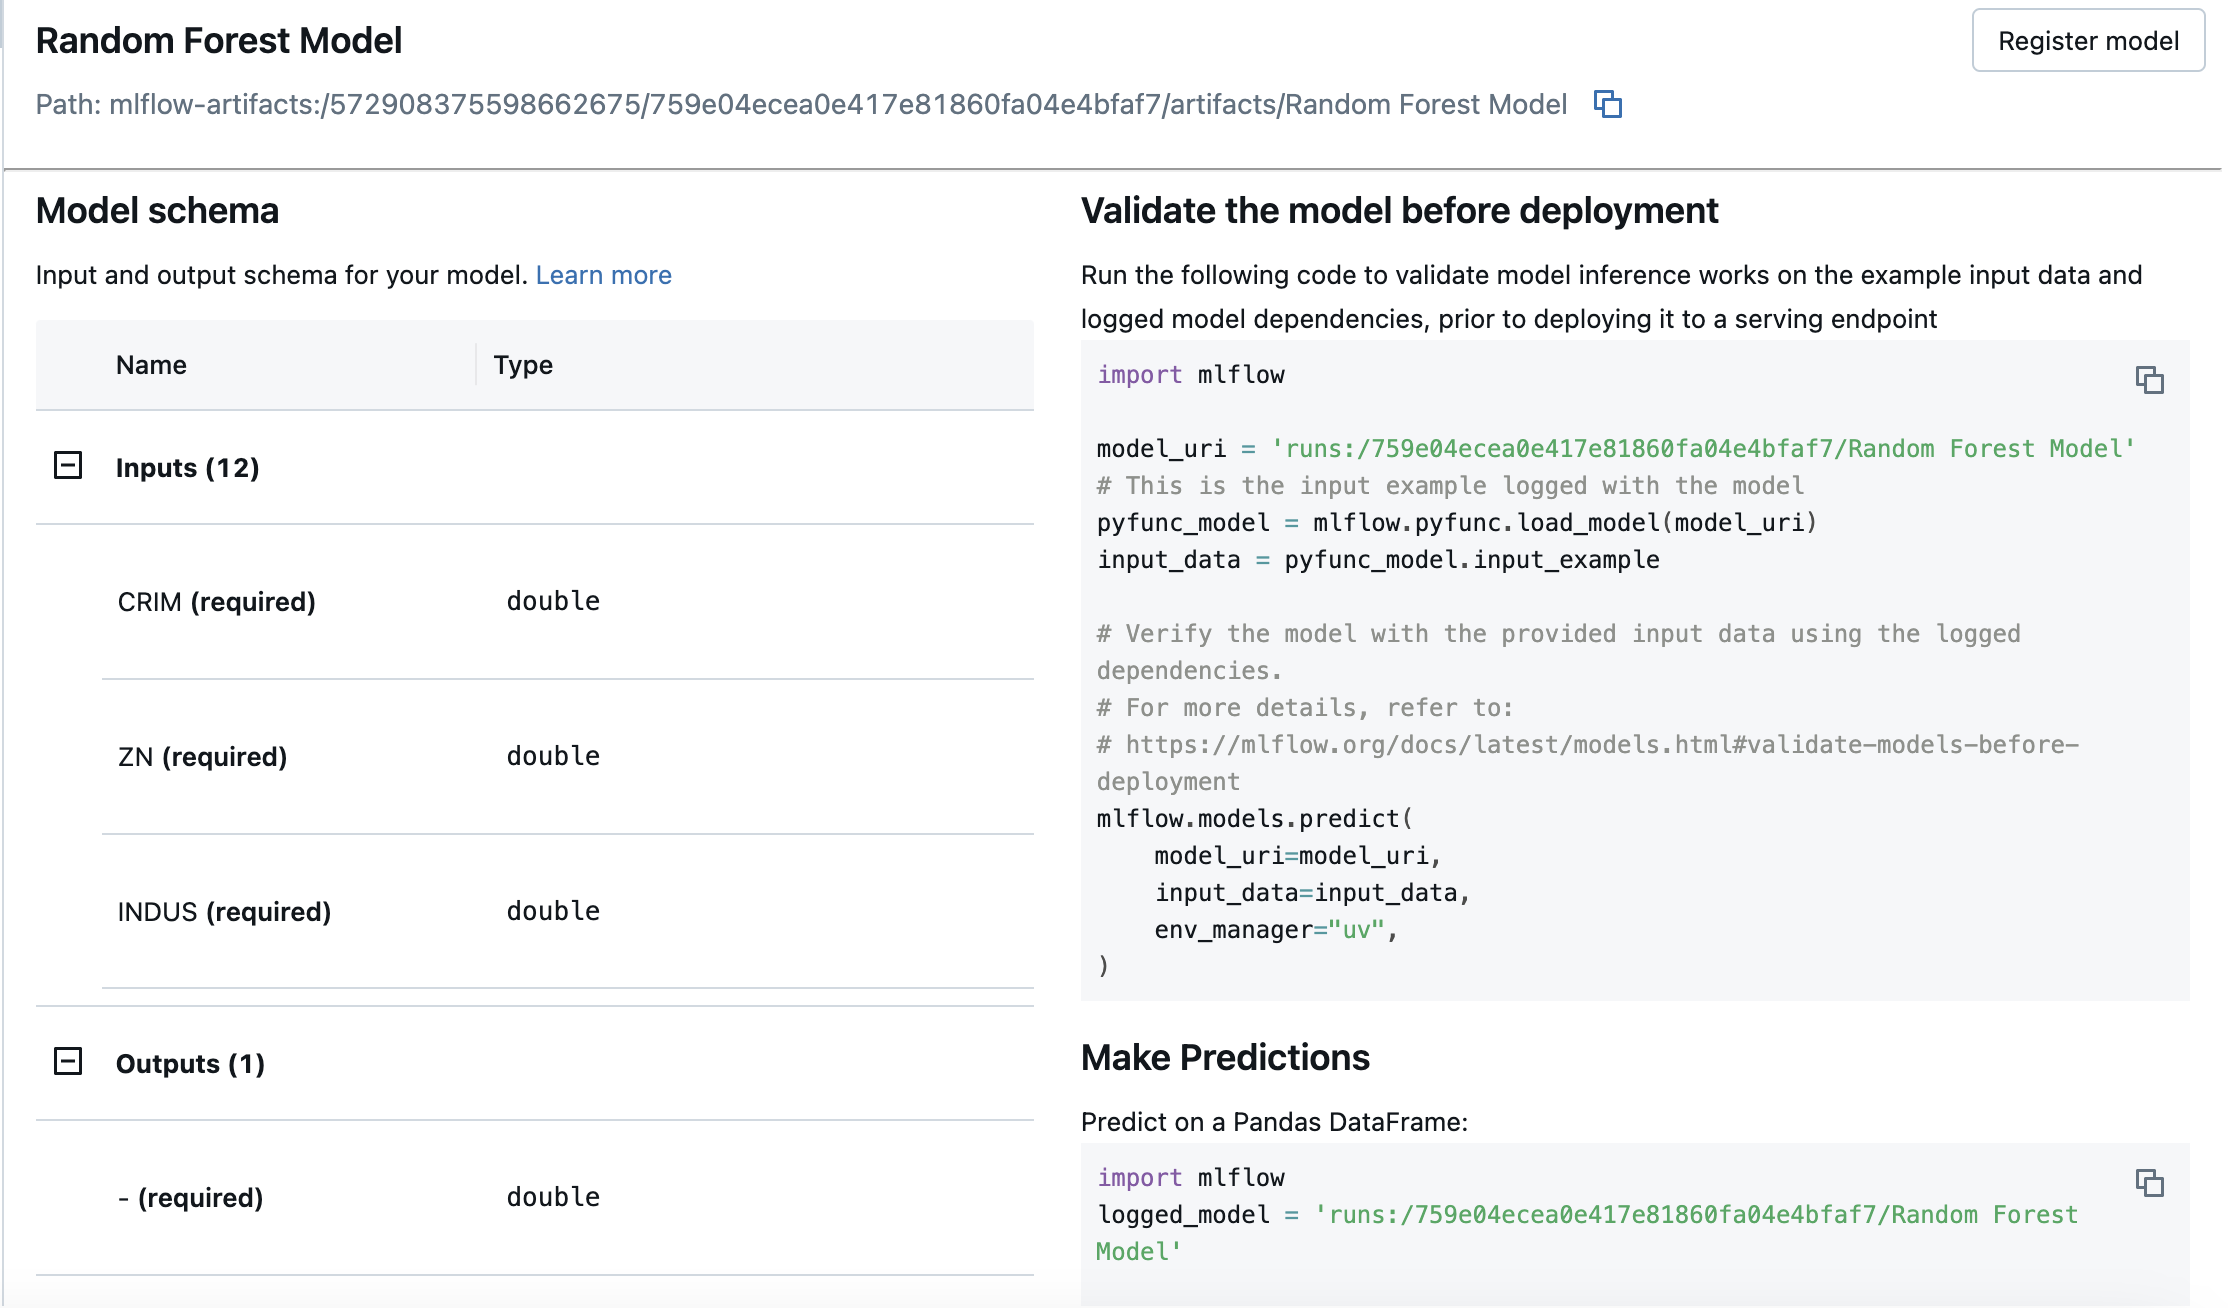

### Carregando modelo registrado do MLFlow

In [10]:
mlflow.search_registered_models()


[<RegisteredModel: aliases={}, creation_timestamp=1737990702483, description='', last_updated_timestamp=1738066062461, latest_versions=[<ModelVersion: aliases=[], creation_timestamp=1738066062461, current_stage='None', description='', last_updated_timestamp=1738066062461, name='rf-model-5', run_id='e4dacdb08baf4efcbea269210c45f176', run_link='', source='file:///C:/Users/pvini/Downloads/code-assignment/code-assignment/mlruns/1/e4dacdb08baf4efcbea269210c45f176/artifacts/rf-model', status='READY', status_message=None, tags={}, user_id='', version='2'>], name='rf-model-5', tags={}>]

In [11]:
! pip install uv 


[notice] A new release of pip is available: 24.1.1 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


### EXEMPLO DADO PELO MLFLOW PARA TESTAR A INFERÊNCIA

In [12]:


import mlflow

model_uri = 'runs:/ff6db848f6b44367a5a2f3d93e101c58/rf-model-5'
# This is the input example logged with the model
pyfunc_model = mlflow.pyfunc.load_model(model_uri)
input_data = pyfunc_model.input_example

# Verify the model with the provided input data using the logged dependencies.
# For more details, refer to:
# https://mlflow.org/docs/latest/models.html#validate-models-before-deployment
pyfunc_model.predict(
    input_data
)

array([0.47256074])